# Medical Diagnosis AID

Dataset: PIMA Indians Diabetes Database

Notebook goal: 
Explore the dataset, perform minimal preprocessing of data, train baseline machine learning models, and compare their performance for diabetes prediction.

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


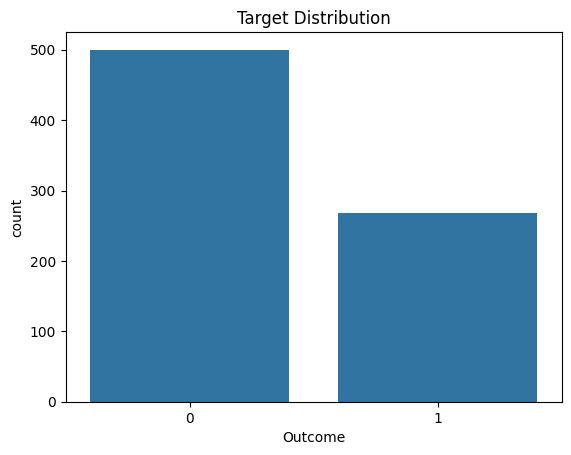

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the project data folder
df = pd.read_csv("../data/diabetes.csv")

# Inspect the available columns
print(df.columns.tolist())

# Check the class distribution
print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize=True))

# Plot the target distribution
sns.countplot(data=df, x="Outcome")
plt.title("Target Distribution")
plt.show()

The target variable is 'Outcome', where '0' means no diabetes and '1' means  diabetes.
The dataset is moderately imbalanced, with more negative cases than positive cases.

In [32]:
# Select all numeric columns to inspect zero values globally
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numeric_columns:
    # Count how many zeros appear in each numeric column
    zero_count = (df[column] == 0).sum()
    print(f"{column}: {zero_count}")

Pregnancies: 111
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11
DiabetesPedigreeFunction: 0
Age: 0
Outcome: 500


Zero values were checked across all numeric columns.
- `Pregnancies = 0` is a plausible value because it can represent a patient with no previous pregnancies, so it is not treated as missing.
- `Outcome = 0` is also a valid class label, not a missing value.
- For `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`, zero values are clinically implausible, so they will be considered as missing during preprocessing.

The choice is based on data meaning, not only on correlation with diabetes.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


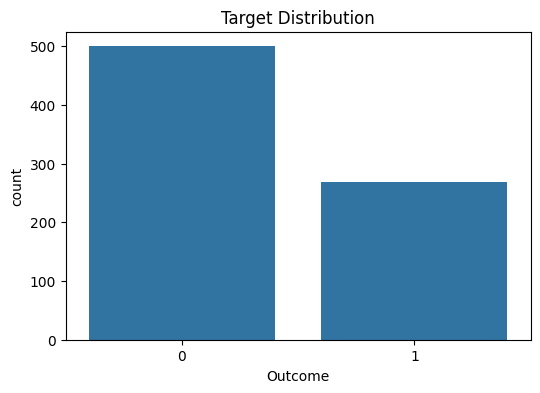

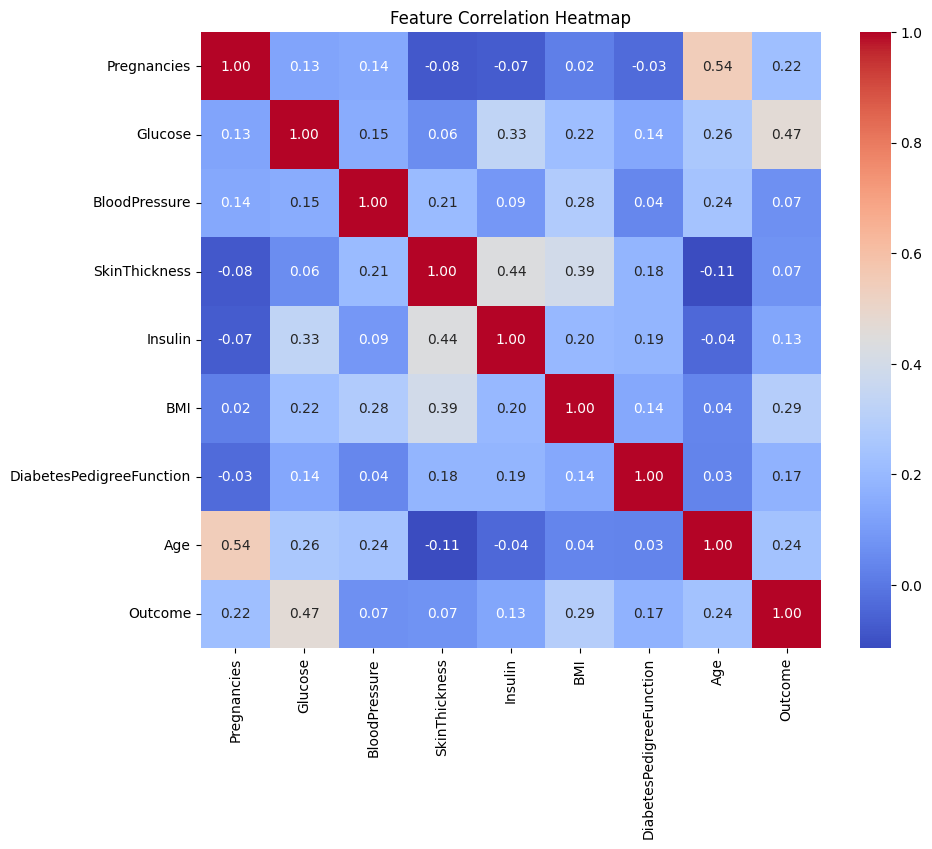

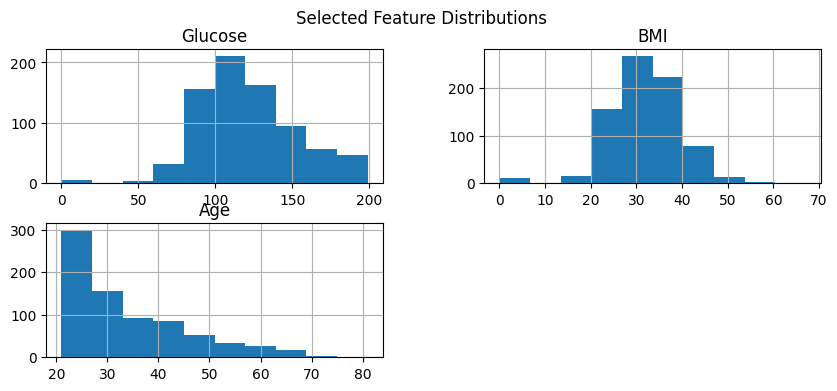

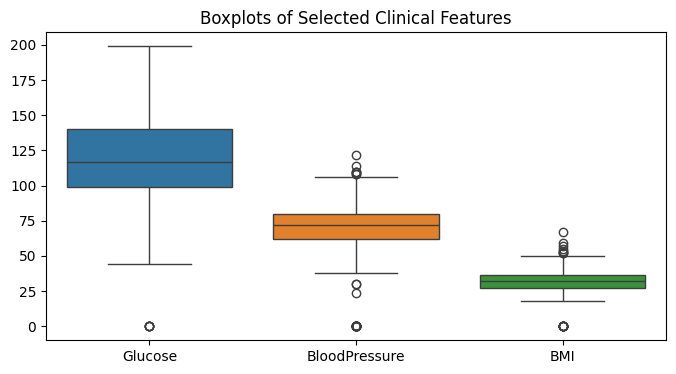

In [33]:
# Display a quick preview of the dataset
display(df.head())

# Show dataset structure and summary statistics
print(df.info())
display(df.describe())

# Plot the target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Outcome")
plt.title("Target Distribution")
plt.show()

# Plot feature correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

# Plot selected feature distributions
df[["Glucose", "BMI", "Age"]].hist(figsize=(10, 4))
plt.suptitle("Selected Feature Distributions")
plt.show()

# Plot boxplots to inspect spread and possible outliers
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[["Glucose", "BloodPressure", "BMI"]])
plt.title("Boxplots of Selected Clinical Features")
plt.show()

`Outcome` is not perfectly balanced, so accuracy alone may not be enough.

`Glucose` appears positively related to the target and is likely one of the most informative features.

Some clinical variables contain suspicious zero values and possible outliers, so minimal preprocessing is needed before training.

In [34]:
# Work on a copy to preserve the original dataset
clean_df = df.copy()

# Columns where zero likely means a missing or invalid measurement
columns_with_suspicious_zeros = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
]

for column in columns_with_suspicious_zeros:
    # Replace suspicious zeros with missing values
    clean_df[column] = clean_df[column].replace(0, np.nan)
    # Fill missing values with the median of the column
    clean_df[column] = clean_df[column].fillna(clean_df[column].median())

# Separate features and target
X = clean_df.drop("Outcome", axis=1)
y = clean_df["Outcome"]

Zero values were not treated uniformly across all columns.
- `Pregnancies` was left unchanged because zero is a meaningful value for that feature.
- `Outcome` was also left unchanged because it is the target label.
- Suspicious zero values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` were replaced with missing values and then imputed using the median of each feature.

This keeps preprocessing simple, explainable, and appropriate for a first MVP.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train a simple baseline model
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

# Predict the target on the test set
y_pred_baseline = baseline_model.predict(X_test)

Logistic Regression is used as a baseline because it is simple, fast, and appropriate for binary classification on tabular data.

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Train a second model for comparison
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the same test set
y_pred_rf = rf_model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = []

# Store baseline metrics
results.append({
    "model": "LogisticRegression",
    "accuracy": accuracy_score(y_test, y_pred_baseline),
    "precision": precision_score(y_test, y_pred_baseline),
    "recall": recall_score(y_test, y_pred_baseline),
    "f1": f1_score(y_test, y_pred_baseline),
})

# Store Random Forest metrics
results.append({
    "model": "RandomForestClassifier",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
})

# Convert results to a DataFrame for easy comparison
results_df = pd.DataFrame(results)
display(results_df)

# Print confusion matrices for deeper inspection
print("Baseline confusion matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

print("Random Forest confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

,model,accuracy,precision,recall,f1
0,LogisticRegression,0.701299,0.586957,0.500000,0.540000
1,RandomForestClassifier,0.779221,0.727273,0.592593,0.653061


Baseline confusion matrix:
[[81 19]
 [27 27]]
Random Forest confusion matrix:
[[88 12]
 [22 32]]


I choose to use the RandomForestClassifier Model.
It was selected by comparing classification metrics on the same test split.
RandomForestClassifier offers the best balance between predictive performance and simplicity for this MVP.

In [38]:
import joblib

# I Chose the final model, RandomForestClassified, and saved it to disk
final_model = rf_model
joblib.dump(final_model, "../models/diabetes_model.joblib")

['../models/diabetes_model.joblib']